In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install imbalanced-learn and xgboost
!pip install -q imbalanced-learn xgboost

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
# Load Data
file_path = '/content/drive/MyDrive/GSE65683_ClusterData_PercRank_GEOsubmission.xlsx'
df = pd.read_excel(file_path)

In [ ]:
# Prepare Data
metadata_cols = ['chr', 'start', 'end', 'Element name', 'strand']
expression_df = df.drop(columns=metadata_cols).T
expression_df.columns = df['Element name']
expression_df.index.name = 'SampleID'

In [ ]:
# Label Mapping
group_labels = {
    **{f'S{i}': 0 for i in range(1, 8)},       # Natural conception LB
    **{f'S{i}': 1 for i in range(8, 37)},      # IUI or TIC
    **{f'S{i}': 2 for i in range(37, 51)},     # Failed IUI → ART
    **{f'S{i}': 3 for i in range(51, 64)},     # Voluntary ART
    **{f'H{i}': 4 for i in range(1, 6)},       # External clinic LB
    **{f'S{i}': 5 for i in range(64, 68)},     # Suspected female factor
}
expression_df['Label'] = expression_df.index.map(group_labels)
expression_df = expression_df.dropna(subset=['Label'])

<ipython-input-6-514ba086ded0>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=expression_df, palette='viridis')


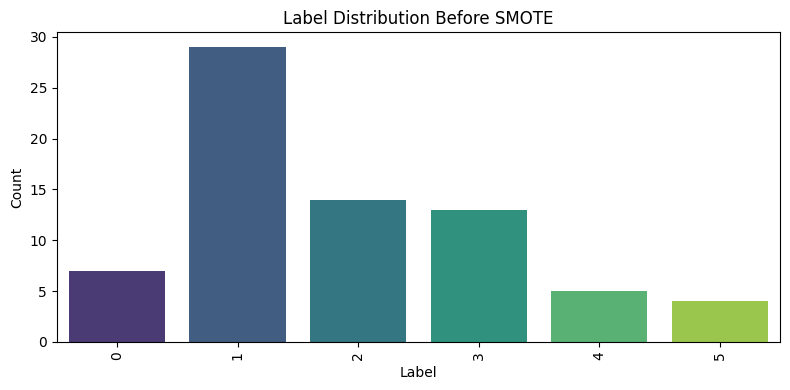


 Label Descriptions:
Label 0: I: Natural conception LB
Label 1: II-i: IUI/TIC Success
Label 2: II-ii: Failed IUI → ART
Label 3: II-iii: Voluntary ART
Label 4: III-i: External clinic LB
Label 5: III-ii: Suspected female factor


In [ ]:
# EDA Before SMOTE
plt.figure(figsize=(8, 4))
sns.countplot(x='Label', data=expression_df, palette='viridis')
plt.xticks(rotation=90)
plt.title("Label Distribution Before SMOTE")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

label_map = {
    0: "I: Natural conception LB",
    1: "II-i: IUI/TIC Success",
    2: "II-ii: Failed IUI → ART",
    3: "II-iii: Voluntary ART",
    4: "III-i: External clinic LB",
    5: "III-ii: Suspected female factor"
}
print("\n Label Descriptions:")
for k, v in label_map.items():
    print(f"Label {k}: {v}")

In [ ]:
# Preprocessing
X = expression_df.drop(columns='Label')
y = expression_df['Label'].astype(int)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# SMOTE
min_class_size = min(y.value_counts().values)
k_neighbors = min_class_size - 1 if min_class_size > 1 else 1
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

<ipython-input-9-d938bded3531>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette='plasma')


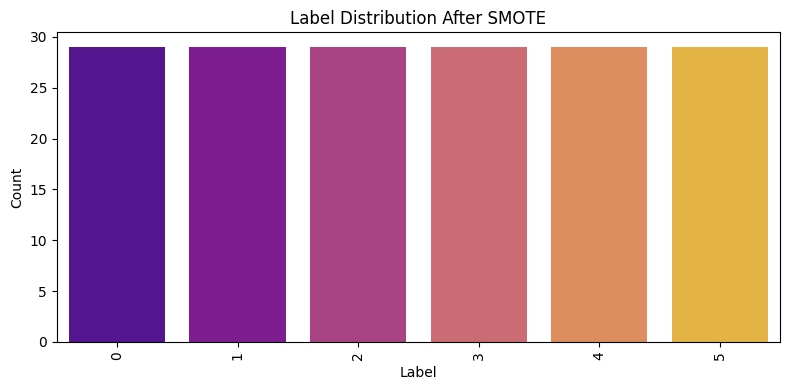

In [ ]:
# EDA After SMOTE
plt.figure(figsize=(8, 4))
sns.countplot(x=y_resampled, palette='plasma')
plt.xticks(rotation=90)
plt.title("Label Distribution After SMOTE")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# Class Weights
classes = np.unique(y_resampled)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_resampled)
class_weights = dict(zip(classes, weights))

# Helper: Confusion Matrix Heatmap
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False, square=True)
    plt.title(title, fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Helper: Top Genes Plot
def top_genes(model, model_name):
    importances = model.feature_importances_
    top_indices = np.argsort(importances)[::-1][:20]
    top_genes = X.columns[top_indices]
    plt.figure(figsize=(10, 5))
    plt.barh(top_genes[::-1], importances[top_indices][::-1], color='teal')
    plt.title(f"Top 20 Genes - {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(f"Top 20 Genes for {model_name}:")
    for i, gene in enumerate(top_genes):
        print(f"{i+1}. {gene} ({importances[top_indices[i]]:.4f})")



Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      0.83      0.91         6
           2       0.86      1.00      0.92         6
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00         6
           5       1.00      1.00      1.00         6

    accuracy                           0.97        35
   macro avg       0.98      0.97      0.97        35
weighted avg       0.98      0.97      0.97        35



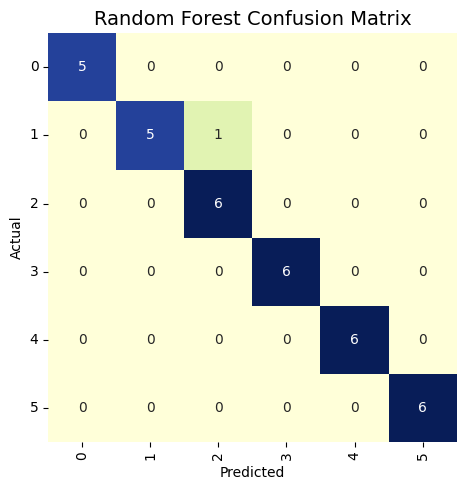

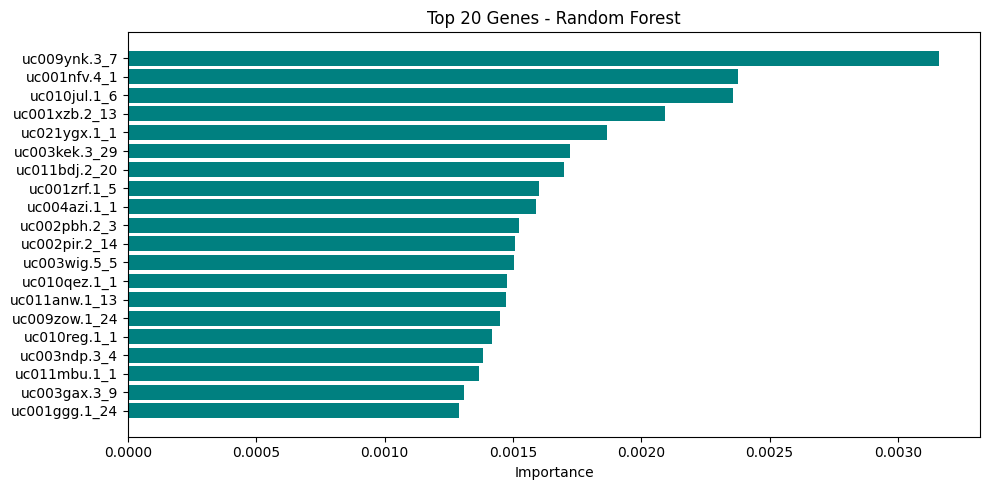

Top 20 Genes for Random Forest:
1. uc009ynk.3_7 (0.0032)
2. uc001nfv.4_1 (0.0024)
3. uc010jul.1_6 (0.0024)
4. uc001xzb.2_13 (0.0021)
5. uc021ygx.1_1 (0.0019)
6. uc003kek.3_29 (0.0017)
7. uc011bdj.2_20 (0.0017)
8. uc001zrf.1_5 (0.0016)
9. uc004azi.1_1 (0.0016)
10. uc002pbh.2_3 (0.0015)
11. uc002pir.2_14 (0.0015)
12. uc003wig.5_5 (0.0015)
13. uc010qez.1_1 (0.0015)
14. uc011anw.1_13 (0.0015)
15. uc009zow.1_24 (0.0015)
16. uc010reg.1_1 (0.0014)
17. uc003ndp.3_4 (0.0014)
18. uc011mbu.1_1 (0.0014)
19. uc003gax.3_9 (0.0013)
20. uc001ggg.1_24 (0.0013)


In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight=class_weights, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")
top_genes(rf, "Random Forest")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:05:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.75      0.50      0.60         6
           2       0.67      1.00      0.80         6
           3       1.00      0.83      0.91         6
           4       1.00      1.00      1.00         6
           5       1.00      1.00      1.00         6

    accuracy                           0.89        35
   macro avg       0.90      0.89      0.88        35
weighted avg       0.90      0.89      0.88        35



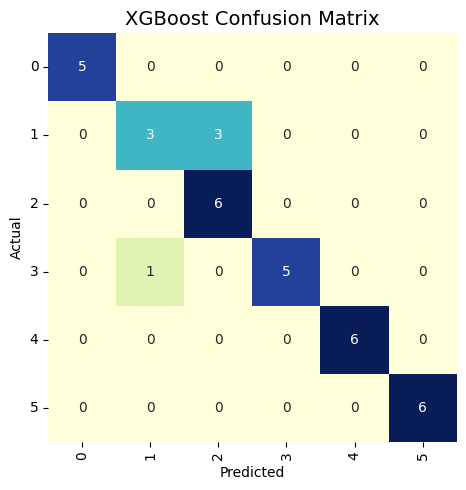

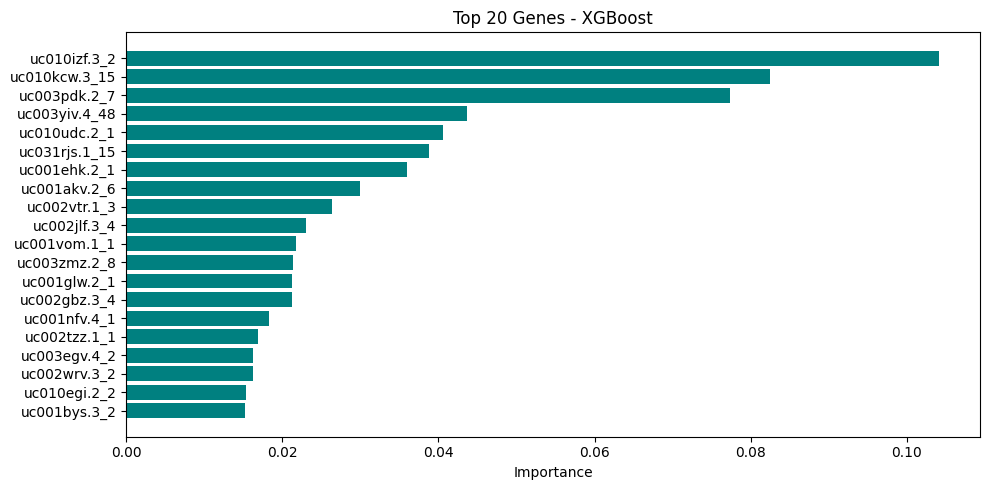

Top 20 Genes for XGBoost:
1. uc010izf.3_2 (0.1042)
2. uc010kcw.3_15 (0.0825)
3. uc003pdk.2_7 (0.0774)
4. uc003yiv.4_48 (0.0437)
5. uc010udc.2_1 (0.0406)
6. uc031rjs.1_15 (0.0388)
7. uc001ehk.2_1 (0.0360)
8. uc001akv.2_6 (0.0299)
9. uc002vtr.1_3 (0.0264)
10. uc002jlf.3_4 (0.0231)
11. uc001vom.1_1 (0.0217)
12. uc003zmz.2_8 (0.0214)
13. uc001glw.2_1 (0.0213)
14. uc002gbz.3_4 (0.0212)
15. uc001nfv.4_1 (0.0183)
16. uc002tzz.1_1 (0.0169)
17. uc003egv.4_2 (0.0162)
18. uc002wrv.3_2 (0.0162)
19. uc010egi.2_2 (0.0153)
20. uc001bys.3_2 (0.0152)


In [ ]:
# XGBoost (faster eval_metric)
xgb = XGBClassifier(objective='multi:softmax', num_class=len(classes), eval_metric='mlogloss',
                    use_label_encoder=False, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("\nXGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
plot_conf_matrix(y_test, y_pred_xgb, "XGBoost Confusion Matrix")
top_genes(xgb, "XGBoost")


SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.86      1.00      0.92         6
           2       1.00      1.00      1.00         6
           3       1.00      0.83      0.91         6
           4       1.00      1.00      1.00         6
           5       1.00      1.00      1.00         6

    accuracy                           0.97        35
   macro avg       0.98      0.97      0.97        35
weighted avg       0.98      0.97      0.97        35



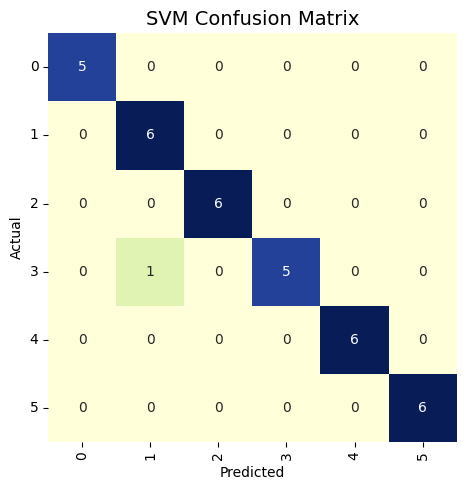

In [ ]:
# SVM (skip top genes due to kernel)
svm = SVC(kernel='rbf', class_weight='balanced', probability=False, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))
plot_conf_matrix(y_test, y_pred_svm, "SVM Confusion Matrix")

In [ ]:
# Fast Cross-Validation
print("\n 10-Fold Cross-Validation:")
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rf_cv = cross_val_score(rf, X_resampled, y_resampled, cv=cv, scoring='accuracy')
xgb_cv = cross_val_score(xgb, X_resampled, y_resampled, cv=cv, scoring='accuracy')
svm_cv = cross_val_score(svm, X_resampled, y_resampled, cv=cv, scoring='accuracy')

print(f" Random Forest: {np.mean(rf_cv):.4f} ± {np.std(rf_cv):.4f}")
print(f" XGBoost:       {np.mean(xgb_cv):.4f} ± {np.std(xgb_cv):.4f}")
print(f" SVM:           {np.mean(svm_cv):.4f} ± {np.std(svm_cv):.4f}")


 10-Fold Cross-Validation:


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:12:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:20:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:27:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:35:22] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:42:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

 Random Forest: 0.9209 ± 0.0966
 XGBoost:       0.8333 ± 0.0827
 SVM:           0.9425 ± 0.0016


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.00      0.00      0.00         6
           2       0.67      1.00      0.80         6
           3       1.00      0.83      0.91         6
           4       0.75      1.00      0.86         6
           5       0.75      1.00      0.86         6

    accuracy                           0.80        35
   macro avg       0.69      0.81      0.74        35
weighted avg       0.69      0.80      0.73        35



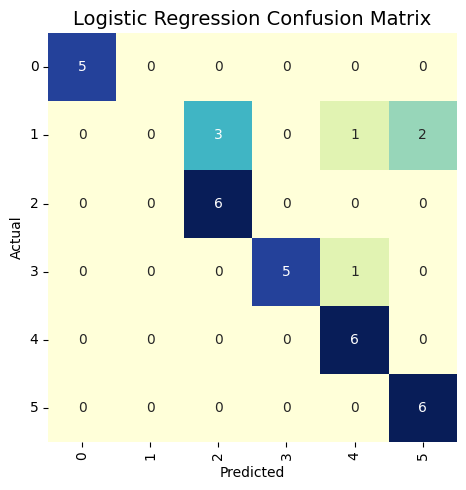

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.173550 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5938671
[LightGBM] [Info] Number of data points in the train set: 139, number of used features: 195716
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



LightGBM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.80      0.67      0.73         6
           2       0.86      1.00      0.92         6
           3       0.83      0.83      0.83         6
           4       1.00      1.00      1.00         6
           5       1.00      1.00      1.00         6

    accuracy                           0.91        35
   macro avg       0.92      0.92      0.91        35
weighted avg       0.91      0.91      0.91        35



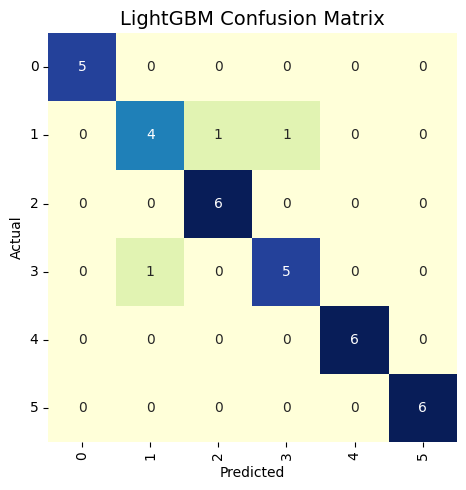

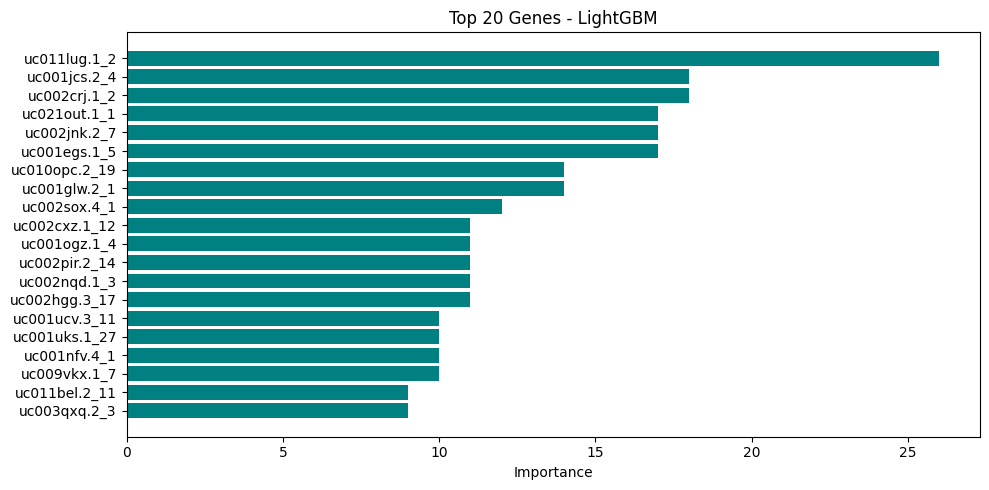

Top 20 Genes for LightGBM:
1. uc011lug.1_2 (26.0000)
2. uc001jcs.2_4 (18.0000)
3. uc002crj.1_2 (18.0000)
4. uc021out.1_1 (17.0000)
5. uc002jnk.2_7 (17.0000)
6. uc001egs.1_5 (17.0000)
7. uc010opc.2_19 (14.0000)
8. uc001glw.2_1 (14.0000)
9. uc002sox.4_1 (12.0000)
10. uc002cxz.1_12 (11.0000)
11. uc001ogz.1_4 (11.0000)
12. uc002pir.2_14 (11.0000)
13. uc002nqd.1_3 (11.0000)
14. uc002hgg.3_17 (11.0000)
15. uc001ucv.3_11 (10.0000)
16. uc001uks.1_27 (10.0000)
17. uc001nfv.4_1 (10.0000)
18. uc009vkx.1_7 (10.0000)
19. uc011bel.2_11 (9.0000)
20. uc003qxq.2_3 (9.0000)


In [ ]:
!pip install lightgbm -q
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print("\nLightGBM Classification Report:\n", classification_report(y_test, y_pred_lgbm))
plot_conf_matrix(y_test, y_pred_lgbm, "LightGBM Confusion Matrix")
top_genes(lgbm, "LightGBM")
